# Comparativa de Modelos de Clasificación — Árbol de Decisión vs Random Forest vs XGBoost

---

**Autor:** Borja Mora Méndez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoría:** Machine Learning · Supervisado · Clasificación · Comparativa de modelos

---

### Objetivo

Comparar de forma rigurosa los tres modelos de clasificación entrenados para predecir la satisfacción de clientes de un gimnasio urbano — **Árbol de Decisión**, **Random Forest** y **XGBoost** — y determinar cuál ofrece el mejor equilibrio entre rendimiento, interpretabilidad y utilidad de negocio.

### Contexto de negocio

**El cliente:** cadena de gimnasios urbanos con múltiples sedes.

**El problema:** la dirección necesita predecir qué clientes están insatisfechos para actuar antes de que se den de baja. Se han entrenado tres modelos sobre los mismos datos operativos. Este notebook evalúa cuál debería desplegarse en producción.

## 1️. Setup: librerías y configuración visual

In [1]:
# Librerías base
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Preprocesamiento
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

# Modelos
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Métricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve,
)
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings('ignore')

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

# Estilo visual
PURPLE = '#7a7bff'
GREEN  = '#6E7F5B'
RED    = '#C2412E'
GRAY   = '#F4EFE6'
INK    = '#2B2118'
MUTED  = '#bfbfbf'

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': MUTED,
    'axes.labelcolor': INK,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.titlecolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'font.family': 'sans-serif',
    'font.size': 10,
    'grid.color': '#f0f0f0',
    'grid.linewidth': 0.5,
})

## 2. Carga de datos y preparación

In [2]:
data = pd.read_excel("gym_clientes.xlsx")
print(f"Registros: {data.shape[0]} | Columnas: {data.shape[1]}")
data.head()

Registros: 300 | Columnas: 7


,ID_Cliente,Antiguedad_Meses,Asistencias_Mes,Horas_Pico_Mes,Gasto_Mensual_Extra,Satisfecho,Abandono
0,1,29,1,8.673509,64.161055,0,1
1,2,15,1,4.396600,32.554177,0,0
2,3,8,22,22.313433,85.092643,1,0
3,4,21,21,20.598791,120.709423,1,0
4,5,19,18,18.783644,103.148141,1,0


In [3]:
# Variables predictoras y target
X = data[["Antiguedad_Meses", "Asistencias_Mes", "Horas_Pico_Mes", "Gasto_Mensual_Extra"]]
y = data["Satisfecho"]

# Mismo split que en los notebooks individuales
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} registros ({y_train.mean():.1%} satisfechos)")
print(f"Test:  {X_test.shape[0]} registros ({y_test.mean():.1%} satisfechos)")
print(f"\nClases equilibradas — accuracy es métrica fiable sin ajustes.")

Train: 240 registros (47.9% satisfechos)
Test:  60 registros (48.3% satisfechos)

Clases equilibradas — accuracy es métrica fiable sin ajustes.


## 3. Entrenamiento de los tres modelos

Se utilizan exactamente los mismos hiperparámetros optimizados en cada notebook individual para garantizar la comparabilidad.

In [4]:
# 1. Árbol de Decisión (depth=2) — seleccionado por CV en el notebook individual
dt = DecisionTreeClassifier(max_depth=2, random_state=42)
dt.fit(X_train, y_train)

# 2. Random Forest (100 árboles) — configuración estándar validada por CV
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 3. XGBoost (mejores hiperparámetros del GridSearchCV)
xgb = XGBClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.05,
    eval_metric="logloss", random_state=42, use_label_encoder=False,
)
xgb.fit(X_train, y_train)

print("✓ Árbol de Decisión entrenado (max_depth=2)")
print("✓ Random Forest entrenado (n_estimators=100)")
print("✓ XGBoost entrenado (n_estimators=100, max_depth=4, lr=0.05)")

✓ Árbol de Decisión entrenado (max_depth=2)
✓ Random Forest entrenado (n_estimators=100)
✓ XGBoost entrenado (n_estimators=100, max_depth=4, lr=0.05)


## 4. Comparación de métricas de evaluación

In [5]:
models = {
    "Árbol de Decisión": dt,
    "Random Forest": rf,
    "XGBoost": xgb,
}

results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    results.append({
        "Modelo": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "AUC-ROC": roc_auc_score(y_test, y_proba),
        "Errores": (y_test != y_pred).sum(),
    })

df_results = pd.DataFrame(results).set_index("Modelo")
print("Comparativa de métricas en el conjunto de Test (60 observaciones)")
print("=" * 75)
df_results.style.format({
    "Accuracy": "{:.1%}", "Precision": "{:.1%}", "Recall": "{:.1%}",
    "F1-Score": "{:.1%}", "AUC-ROC": "{:.3f}", "Errores": "{:.0f}"
})

Comparativa de métricas en el conjunto de Test (60 observaciones)


,Accuracy,Precision,Recall,F1-Score,AUC-ROC,Errores
Modelo,,,,,,
Árbol de Decisión,90.0%,89.7%,89.7%,89.7%,0.909,6
Random Forest,90.0%,89.7%,89.7%,89.7%,0.917,6
XGBoost,91.7%,90.0%,93.1%,91.5%,0.917,5


In [6]:
# Tabla resumen formateada
print("Comparativa de métricas — Test set (60 observaciones)")
print("─" * 75)
for _, row in df_results.iterrows():
    print(f"\n  {row.name}")
    print(f"    Accuracy:  {row['Accuracy']:.1%}")
    print(f"    Precision: {row['Precision']:.1%}")
    print(f"    Recall:    {row['Recall']:.1%}")
    print(f"    F1-Score:  {row['F1-Score']:.1%}")
    print(f"    AUC-ROC:   {row['AUC-ROC']:.3f}")
    print(f"    Errores:   {row['Errores']:.0f} / 60")

Comparativa de métricas — Test set (60 observaciones)
───────────────────────────────────────────────────────────────────────────

  Árbol de Decisión
    Accuracy:  90.0%
    Precision: 89.7%
    Recall:    89.7%
    F1-Score:  89.7%
    AUC-ROC:   0.909
    Errores:   6 / 60

  Random Forest
    Accuracy:  90.0%
    Precision: 89.7%
    Recall:    89.7%
    F1-Score:  89.7%
    AUC-ROC:   0.917
    Errores:   6 / 60

  XGBoost
    Accuracy:  91.7%
    Precision: 90.0%
    Recall:    93.1%
    F1-Score:  91.5%
    AUC-ROC:   0.917
    Errores:   5 / 60


## 5. Visualización comparativa

### 5.1 Métricas lado a lado

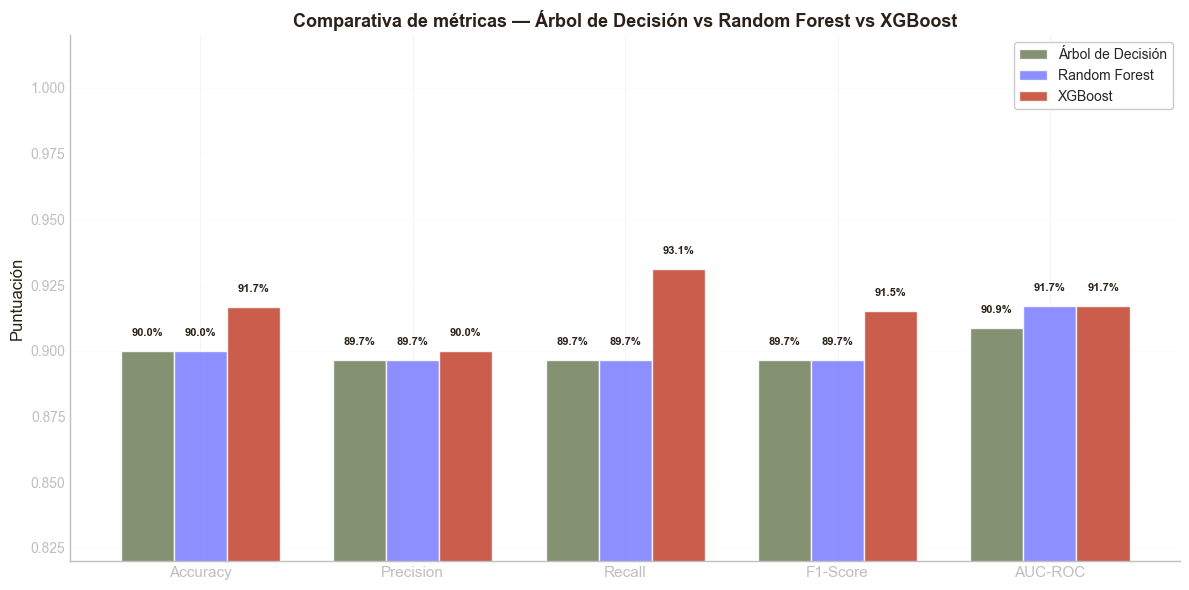

In [7]:
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC"]
model_names = df_results.index.tolist()
colors = [GREEN, PURPLE, RED]

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(metrics))
width = 0.25

for i, (name, color) in enumerate(zip(model_names, colors)):
    values = [df_results.loc[name, m] for m in metrics]
    bars = ax.bar(x + i * width, values, width, label=name, color=color, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{v:.1%}", ha='center', va='bottom', fontsize=8, fontweight='bold', color=INK)

ax.set_ylabel("Puntuación", fontsize=12)
ax.set_title("Comparativa de métricas — Árbol de Decisión vs Random Forest vs XGBoost",
             fontsize=13, fontweight="bold", color=INK)
ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0.82, 1.02)
ax.legend(fontsize=10, frameon=True, facecolor='white', edgecolor=MUTED)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 5.2 Matrices de confusión

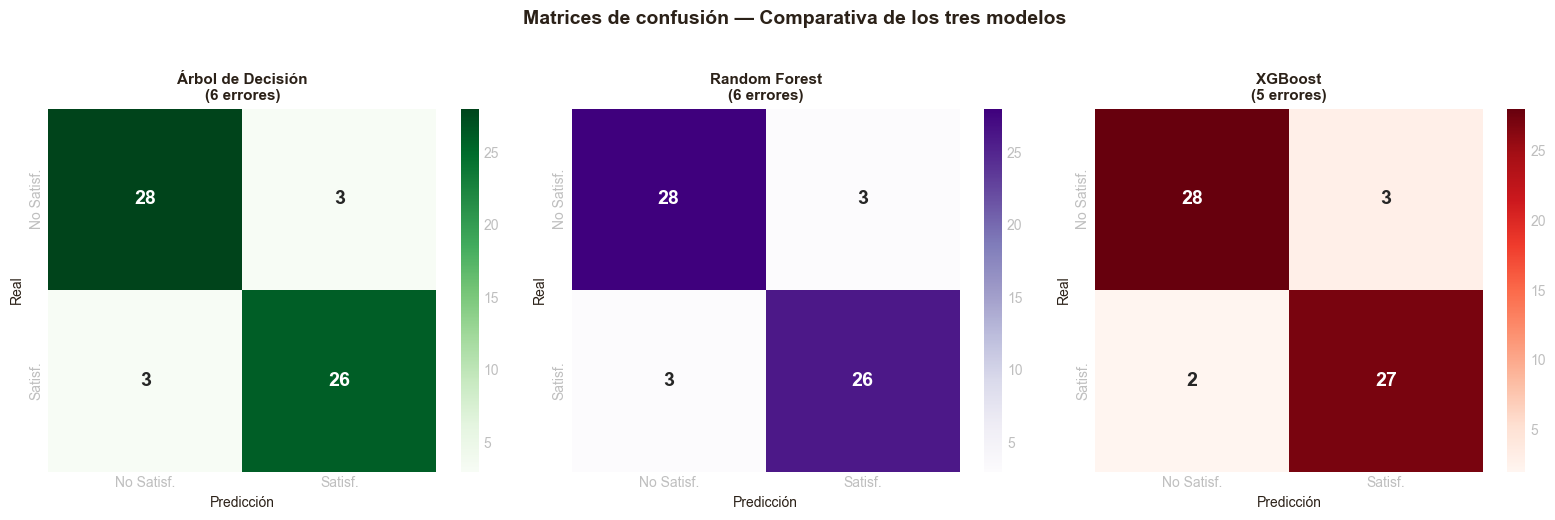

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cmaps = ["Greens", "Purples", "Reds"]
model_list = list(models.items())

for ax, (name, model), cmap in zip(axes, model_list, cmaps):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap,
                xticklabels=["No Satisf.", "Satisf."],
                yticklabels=["No Satisf.", "Satisf."], ax=ax,
                annot_kws={"size": 14, "weight": "bold"})
    errors = cm[0,1] + cm[1,0]
    ax.set_title(f"{name}\n({errors} errores)", fontsize=11, fontweight="bold")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")

plt.suptitle("Matrices de confusión — Comparativa de los tres modelos",
             fontsize=14, fontweight="bold", color=INK, y=1.03)
plt.tight_layout()
plt.show()

### 5.3 Curvas ROC

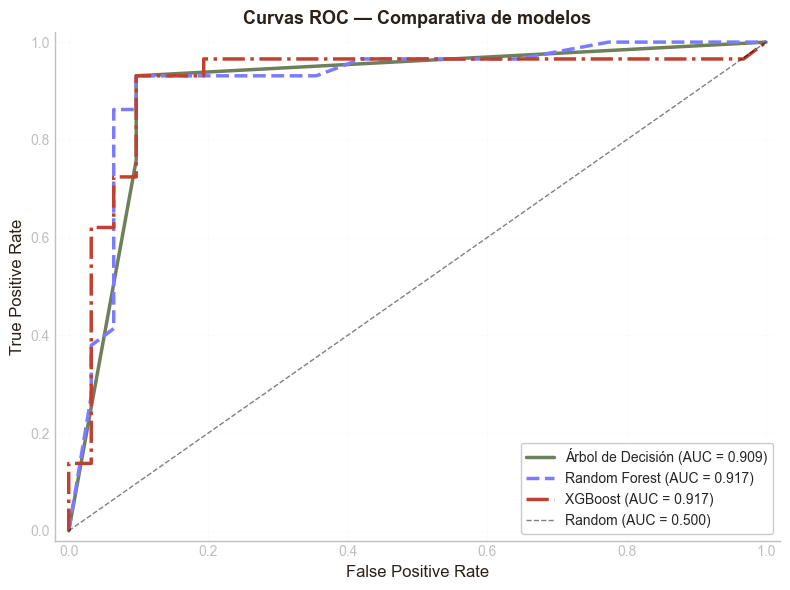

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

line_styles = ['-', '--', '-.']
line_colors = [GREEN, PURPLE, RED]

for (name, model), ls, lc in zip(models.items(), line_styles, line_colors):
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, linestyle=ls, color=lc, linewidth=2.5,
            label=f"{name} (AUC = {auc_val:.3f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Random (AUC = 0.500)")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("Curvas ROC — Comparativa de modelos", fontsize=13, fontweight="bold", color=INK)
ax.legend(fontsize=10, loc="lower right", frameon=True, facecolor='white', edgecolor=MUTED)
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)

plt.tight_layout()
plt.show()

### 5.4 Validación cruzada comparativa

La evaluación sobre el test set puede depender de la partición concreta. La validación cruzada 5-fold ofrece una estimación más robusta del rendimiento real de cada modelo.

Árbol de Decisión         | CV Accuracy: 0.9000 ± 0.0534
Random Forest             | CV Accuracy: 0.9125 ± 0.0517
XGBoost                   | CV Accuracy: 0.9208 ± 0.0610


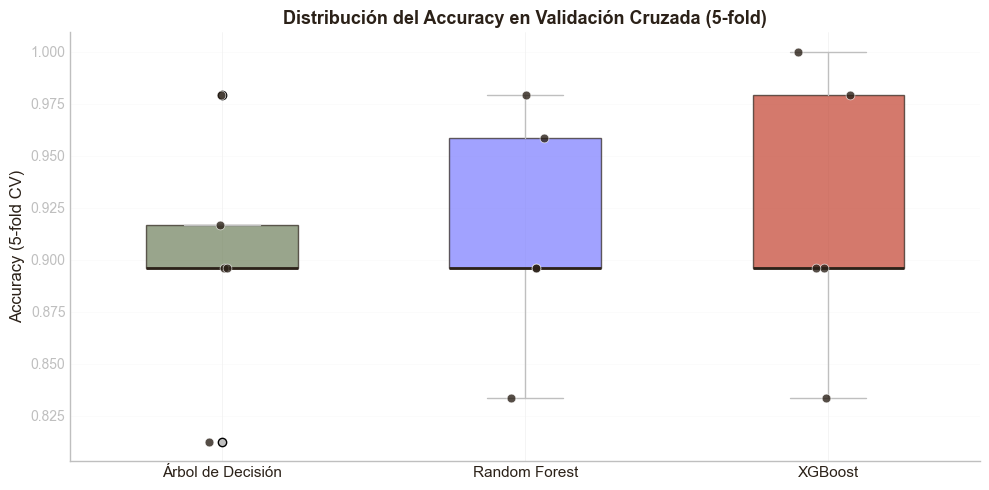

In [10]:
cv_data = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
    cv_data[name] = scores
    print(f"{name:25s} | CV Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

# Boxplot de los scores CV
fig, ax = plt.subplots(figsize=(10, 5))

positions = [1, 2, 3]
box_colors = [GREEN, PURPLE, RED]
bp = ax.boxplot(
    [cv_data[n] for n in model_names],
    positions=positions, widths=0.5, patch_artist=True,
    medianprops=dict(color=INK, linewidth=2),
    whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED),
    flierprops=dict(markerfacecolor=MUTED, marker='o', markersize=6)
)

for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
    patch.set_edgecolor(INK)

# Añadir puntos individuales
for i, name in enumerate(model_names):
    scores = cv_data[name]
    x = np.random.normal(positions[i], 0.04, size=len(scores))
    ax.scatter(x, scores, alpha=0.8, color=INK, s=40, zorder=5, edgecolors='white', linewidth=0.5)

ax.set_xticklabels(model_names, fontsize=11, color=INK)
ax.set_ylabel("Accuracy (5-fold CV)", fontsize=12)
ax.set_title("Distribución del Accuracy en Validación Cruzada (5-fold)",
             fontsize=13, fontweight="bold", color=INK)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Importancia de variables — Comparativa

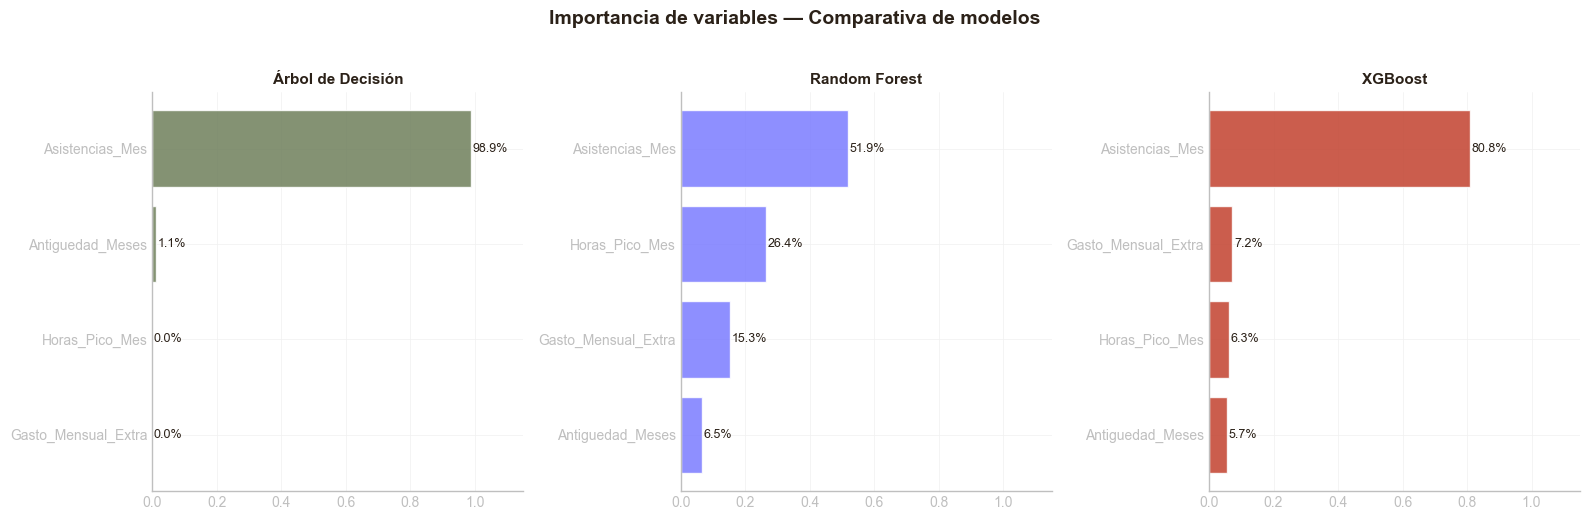

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
bar_colors = [GREEN, PURPLE, RED]

for ax, (name, model), color in zip(axes, models.items(), bar_colors):
    imp = pd.DataFrame({
        "feature": X.columns,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=True)
    
    bars = ax.barh(imp["feature"], imp["importance"], color=color, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, imp["importance"]):
        ax.text(v + 0.005, bar.get_y() + bar.get_height()/2, f"{v:.1%}",
                va="center", fontsize=9, color=INK)
    ax.set_title(name, fontsize=11, fontweight="bold")
    ax.set_xlim(0, 1.15)

plt.suptitle("Importancia de variables — Comparativa de modelos",
             fontsize=14, fontweight="bold", color=INK, y=1.03)
plt.tight_layout()
plt.show()

### Lectura de la importancia de variables

Los tres modelos coinciden en un hallazgo fundamental: **`Asistencias_Mes` es la variable dominante** para predecir la satisfacción de los clientes.

- **Árbol de Decisión:** concentra el **98,9%** de la importancia en `Asistencias_Mes`. Con solo 2 niveles de profundidad, el árbol no necesita más variables.
- **Random Forest:** distribuye la importancia de forma más equilibrada (51,9%), pero `Asistencias_Mes` sigue siendo la principal. La diferencia se debe a que el ensemble explora más combinaciones de variables.
- **XGBoost:** asigna el **80,8%** a `Asistencias_Mes`, situándose entre los otros dos modelos en concentración de importancia.

La convergencia de los tres modelos hacia la misma variable refuerza la robustez del hallazgo: la frecuencia de asistencia es, con diferencia, el indicador más potente de satisfacción.

## Tabla resumen — ¿Qué modelo elegir?

In [16]:
# Tabla resumen con todas las dimensiones de comparación
summary = pd.DataFrame({
    "Modelo": ["Árbol de Decisión", "Random Forest", "XGBoost"],
    "Accuracy": ["90,0%", "90,0%", "91,7%"],
    "Recall": ["89,7%", "89,7%", "93,1%"],
    "AUC-ROC": ["0,909", "0,917", "0,917"],
    "Errores (de 60)": [6, 6, 5],
    "Interpretabilidad": ["Alta", "Media", "Baja"],
    "Complejidad": ["Baja", "Media", "Alta"],
    "Tiempo de tuning": ["Mínimo", "Bajo", "Alto (GridSearch)"],
    "Variable clave": ["Asistencias (98,9%)", "Asistencias (51,9%)", "Asistencias (80,8%)"],
}).set_index("Modelo")

print("TABLA RESUMEN — Comparativa de modelos")
print("=" * 90)
for col in summary.columns:
    print(f"\n{col}:")
    for idx in summary.index:
        print(f"  {idx:25s} → {summary.loc[idx, col]}")

TABLA RESUMEN — Comparativa de modelos

Accuracy:
  Árbol de Decisión         → 90,0%
  Random Forest             → 90,0%
  XGBoost                   → 91,7%

Recall:
  Árbol de Decisión         → 89,7%
  Random Forest             → 89,7%
  XGBoost                   → 93,1%

AUC-ROC:
  Árbol de Decisión         → 0,909
  Random Forest             → 0,917
  XGBoost                   → 0,917

Errores (de 60):
  Árbol de Decisión         → 6
  Random Forest             → 6
  XGBoost                   → 5

Interpretabilidad:
  Árbol de Decisión         → Alta
  Random Forest             → Media
  XGBoost                   → Baja

Complejidad:
  Árbol de Decisión         → Baja
  Random Forest             → Media
  XGBoost                   → Alta

Tiempo de tuning:
  Árbol de Decisión         → Mínimo
  Random Forest             → Bajo
  XGBoost                   → Alto (GridSearch)

Variable clave:
  Árbol de Decisión         → Asistencias (98,9%)
  Random Forest             → Asistencias

## Veredicto final — ¿Cuál es el mejor modelo?

### Resumen de hallazgos

| Dimensión | Árbol de Decisión | Random Forest | XGBoost |
|---|---|---|---|
| **Accuracy** | 90,0% | 90,0% | **91,7%** |
| **Recall** | 89,7% | 89,7% | **93,1%** |
| **AUC-ROC** | 0,909 | **0,917** | **0,917** |
| **Errores** | 6 | 6 | **5** |
| **Complejidad** | **Baja** | Media | Alta |
| **Variable clave** | Asistencias (98,9%) | Asistencias (51,9%) | Asistencias (80,8%) |

### El veredicto

> **Para este problema concreto, el Árbol de Decisión (`max_depth=2`) es el modelo recomendado.**
